In [1]:
#load variables from previous EDA session
import dill

# Restore the entire global namespace
dill.load_session('workspace.pkl')

# Baseline Model

In [2]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
#build lagged historical rent features from hist_rent_df, then merge onto combined_df

#sort chronologically within each property/unit_type series and drop duplicate periods
hist_rent_sorted = hist_rent_df.sort_values(['property_id', 'unit_type', 'period'])
hist_rent_sorted = hist_rent_sorted.drop_duplicates(subset=['property_id', 'unit_type', 'period'])

#create lagged rent columns per property/unit_type group
lag_periods = [1, 3, 6, 12, 24]
grouped = hist_rent_sorted.groupby(['property_id', 'unit_type'])['rent']
for lag in lag_periods:
    hist_rent_sorted[f't_minus_{lag}_rent'] = grouped.shift(lag)

lag_cols = [f't_minus_{lag}_rent' for lag in lag_periods]

#keep just the join keys + lag features
hist_lag_features = hist_rent_sorted[['property_id', 'unit_type', 'period'] + lag_cols]

#merge onto combined_df -- matches each current row to its own historical lag rents at the same period
combined_df = pd.merge(
    combined_df, hist_lag_features,
    how='left',
    left_on=['property_id', 'unit_type_x', 'period'],
    right_on=['property_id', 'unit_type', 'period'],
)

combined_df = combined_df.drop(columns=['unit_type'])  # redundant copy of the right-side merge key

In [4]:
#further cleaning
identical_pairs = []
cols = combined_df.columns.tolist()

for i, col_a in enumerate(cols):
    for col_b in cols[i+1:]:
        s_a = combined_df[col_a]
        s_b = combined_df[col_b]

        mask = s_a.notna() & s_b.notna()
        if mask.sum() == 0:
            continue  # no overlapping non-null values to compare

        if s_a[mask].equals(s_b[mask]):
            identical_pairs.append((col_a, col_b, mask.sum()))

print(f"Found {len(identical_pairs)} identical column pairs (ignoring nulls):")
for col_a, col_b, n in identical_pairs:
    print(f"  {col_a}  ==  {col_b}")

Found 11 identical column pairs (ignoring nulls):
  property_id  ==  source_property_id
  unit_mix_type  ==  unit_type_y
  unit_type_x  ==  unit_configuration
  period  ==  rent_close_date
  period  ==  occupancy_date
  rent  ==  rent_amount
  date_x  ==  date_y
  date_x  ==  date
  rent_close_date  ==  occupancy_date
  date_y  ==  date
  max_stories  ==  number_of_stories


In [5]:
combined_df = combined_df.drop(
    columns=['source_property_id', 'unit_type_y', 'unit_type_x', 'rent_close_date', 
             'occupancy_date', 'rent_amount', 'date_x', 'date_y', 'number_of_stories']
)
combined_df

,property_id,unit_mix_type,unit_garage,period,rent,unit_configuration,has_direct_access_garage,num_units_x,living_area_square_feet,number_of_bedrooms,...,distance_to_downtown,distance_to_atl_airport,five_points_station_lat,five_points_station_lon,distance_to_five_points_station,t_minus_1_rent,t_minus_3_rent,t_minus_6_rent,t_minus_12_rent,t_minus_24_rent
0,22_1004844,Apartment,False,2026-03-01,1657.096802,1BR,False,186.0,685.0,1.0,...,12.753468,20.937695,33.753826,-84.391571,12.852566,1568.967773,1636.387085,1486.806396,1542.806396,1415.064575
1,22_1004844,Apartment,False,2026-03-01,1775.000000,2BR/1Bath,False,36.0,890.0,2.0,...,12.753468,20.937695,33.753826,-84.391571,12.852566,1690.000000,1855.000000,1772.000000,1357.000000,1680.000000
2,22_1004844,Apartment,False,2026-03-01,1889.500000,2BR/2Bath,False,108.0,1090.0,2.0,...,12.753468,20.937695,33.753826,-84.391571,12.852566,1780.500000,1940.500000,1812.000000,1903.000000,1798.000000
3,22_1004844,Apartment,False,2026-03-01,2055.500000,3BR+,False,36.0,1275.0,3.0,...,12.753468,20.937695,33.753826,-84.391571,12.852566,2055.500000,2052.000000,2010.500000,2010.000000,2236.500000
4,22_1004845,Apartment,False,2026-03-01,1690.000000,1BR,False,96.0,840.0,1.0,...,12.694746,20.875448,33.753826,-84.391571,12.792918,1715.000000,1700.000000,1660.000000,1670.000000,1655.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6886,24_99,Apartment,False,2026-03-01,1467.444458,1BR,False,54.0,785.0,1.0,...,21.890867,14.837625,33.753826,-84.391571,21.825465,1379.111084,1469.444458,1443.333374,1448.333374,1391.195068
6887,24_99,Apartment,False,2026-03-01,1582.850464,2BR/2Bath,False,107.0,1243.0,2.0,...,21.890867,14.837625,33.753826,-84.391571,21.825465,1523.635498,1599.738281,1580.420532,1560.420532,1509.000000
6888,24_99,Apartment,False,2026-03-01,1865.000000,3BR+,False,48.0,1479.0,3.0,...,21.890867,14.837625,33.753826,-84.391571,21.825465,1885.000000,1890.000000,1865.000000,1835.000000,1895.000000
6889,24_99,Apartment,True,2026-03-01,1508.000000,1BR,True,28.0,880.0,1.0,...,21.890867,14.837625,33.753826,-84.391571,21.825465,1379.111084,1469.444458,1443.333374,1448.333374,1391.195068


### Build LightGBM Regressor

In [6]:
#create model_df from combined_df
#drop identifiers, free-text, and columns that leak the target

id_and_text_cols = [
    'property_id', 'source_property_id', 'source_name', 'property_name', 'street_address',
    'website', 'owner_name', 'unit_mix',
    'census_cbsa_geoid', 'census_zcta5_geoid', 'census_tract_geoid',
]

date_cols = [
    'period', 'date', 'occupancy_date', 'latest_sale_date', 'latest_sale_price_date', 'rent_close_date',
]

leakage_cols = [
    'rent_amount',                  # same quantity as target 'rent', just carried over from unit_mix_df
    'sub_market_avg_rent',          # combined_df.groupby('sub_market')['rent'].transform('mean') -- derived from target
    'property_average_rent',        # property-level rent aggregate -- derived from target
    'property_average_rent_sqft',   # property-level rent aggregate -- derived from target
]

dup_cols = [c for c in combined_df.columns if c.endswith('_y')]

#drop these cols
drop_cols = [c for c in id_and_text_cols + date_cols + leakage_cols + dup_cols if c in combined_df.columns]

base_model_df = combined_df.drop(columns=drop_cols)

#drop rows with missing rent -- can't train or evaluate on a missing target
base_model_df = base_model_df.dropna(subset=['rent'])

print(f"Dropped {len(drop_cols)} id/date/leakage columns:\n")
print(drop_cols)
print(f"\nbase_model_df shape: {base_model_df.shape}")

Dropped 18 id/date/leakage columns:

['property_id', 'source_name', 'property_name', 'street_address', 'website', 'owner_name', 'unit_mix', 'census_cbsa_geoid', 'census_zcta5_geoid', 'census_tract_geoid', 'period', 'date', 'latest_sale_date', 'latest_sale_price_date', 'sub_market_avg_rent', 'property_average_rent', 'property_average_rent_sqft', 'num_units_y']

base_model_df shape: (6887, 72)


In [7]:
#cast remaining object columns to 'category' dtype so LightGBM can use its native categorical handling
def cast_to_category(df):
    obj_cols = df.select_dtypes(include='object').columns.tolist()
    for col in obj_cols:
        df[col] = df[col].astype('category')
        
    cat_cols = df.select_dtypes(include='category').columns.tolist()
    return cat_cols


cat_cols = cast_to_category(base_model_df)

In [8]:
#target: log-transform rent (log1p) to match the right-skew finding from the earlier EDA
def prepare_cv_data(model_df, combined_df, target_col='rent'):
    X = model_df.drop(columns=[target_col])
    y_log = np.log1p(model_df[target_col])

    #group by property so a property's units never span both sides of a fold
    groups = combined_df.loc[model_df.index, 'property_id']

    print(f"X: {X.shape}, unique properties: {groups.nunique()}")
    return X, y_log, groups


X, y_log, groups = prepare_cv_data(base_model_df, combined_df)

X: (6887, 71), unique properties: 2121


In [9]:
from sklearn.model_selection import GroupKFold

#train LightGBM with GroupKFold cross-validation, returning only the average MAE across folds
def train_model_cv(X, y_log, groups, cat_cols, n_splits=10):
    gkf = GroupKFold(n_splits=n_splits)
    
    params = {
        'objective': 'regression',
        'metric': 'mae',
        'learning_rate': 0.05,
        'num_leaves': 31,
        'min_data_in_leaf': 20,
        'feature_fraction': 0.9,
        'bagging_fraction': 0.8,
        'bagging_freq': 5,
        'verbose': -1,
        'seed': 42
    }

    fold_maes = []

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y_log, groups)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y_log.iloc[train_idx], y_log.iloc[val_idx]

        train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_cols, free_raw_data=False)
        val_data = lgb.Dataset(X_val, label=y_val, categorical_feature=cat_cols, reference=train_data, free_raw_data=False)

        model = lgb.train(
            params,
            train_data,
            num_boost_round=1000,
            valid_sets=[train_data, val_data],
            valid_names=['train', 'valid'],
            callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=50)],
        )

        pred_log = model.predict(X_val, num_iteration=model.best_iteration)
        pred, actual = np.expm1(pred_log), np.expm1(y_val)

        fold_mae = mean_absolute_error(actual, pred)
        fold_maes.append(fold_mae)
        print(f"Fold {fold}: best_iter={model.best_iteration}, MAE=${fold_mae:,.2f}")

    avg_mae = np.mean(fold_maes)
    
    print(f"\nAverage OOF MAE across {n_splits} folds: ${avg_mae:,.2f}\n")
    return avg_mae


base_avg_mae = train_model_cv(X, y_log, groups, cat_cols)

Training until validation scores don't improve for 50 rounds
[50]	train's l1: 0.0388011	valid's l1: 0.0438355
[100]	train's l1: 0.0262978	valid's l1: 0.0363115
[150]	train's l1: 0.0236962	valid's l1: 0.0364489
Early stopping, best iteration is:
[115]	train's l1: 0.0253116	valid's l1: 0.0361676
Fold 0: best_iter=115, MAE=$69.95
Training until validation scores don't improve for 50 rounds
[50]	train's l1: 0.0388775	valid's l1: 0.042746
[100]	train's l1: 0.0263935	valid's l1: 0.0357206
[150]	train's l1: 0.0237299	valid's l1: 0.0357011
Early stopping, best iteration is:
[112]	train's l1: 0.0256132	valid's l1: 0.0355532
Fold 1: best_iter=112, MAE=$75.52
Training until validation scores don't improve for 50 rounds
[50]	train's l1: 0.0392773	valid's l1: 0.0422961
[100]	train's l1: 0.0268256	valid's l1: 0.0341122
[150]	train's l1: 0.0241447	valid's l1: 0.0343724
Early stopping, best iteration is:
[131]	train's l1: 0.0250116	valid's l1: 0.0340352
Fold 2: best_iter=131, MAE=$75.55
Training until

# Potential Geospatial Features

## Transit Score (Nearest MARTA Station)

In [10]:
landmarks_df

,key,name,type,latitude,longitude,source
0,buckhead,Buckhead,neighborhood,33.839420,-84.379920,https://en.wikipedia.org/wiki/Buckhead
1,midtown,Midtown Atlanta,neighborhood,33.786801,-84.379517,https://en.wikipedia.org/wiki/Midtown_Atlanta
2,downtown,Downtown Atlanta,cbd,33.755000,-84.390000,https://en.wikipedia.org/wiki/Downtown_Atlanta
3,atl_airport,Hartsfield-Jackson Atlanta International Airport,airport,33.640700,-84.427700,https://en.wikipedia.org/wiki/Hartsfield-Jacks...
4,five_points_station,Five Points Station,transportation,33.753826,-84.391571,NaN


In [11]:
import json

#create function to load geojsons from OSM
def load_geojson_points(geojson_path, name_key='name'):
    with open(geojson_path) as f:
        geojson_data = json.load(f)

    df = pd.DataFrame([
        {
            'name': feature['properties'].get(name_key, 'Unknown'),
            'latitude': feature['geometry']['coordinates'][1],
            'longitude': feature['geometry']['coordinates'][0]
        }
        for feature in geojson_data['features']
        if feature['geometry']['type'] == 'Point'
    ])

    return df


#load marta geojson
marta_landmarks = load_geojson_points("/Users/njlim21/Desktop/forty5park/prime-mfr/eda/MARTA_stations.geojson")

In [12]:
#add to landmarks_df
landmarks_df = pd.concat([landmarks_df, marta_landmarks], ignore_index=True)

In [13]:
#add data to the key and type columns
def landmarks_df_fill_cols(df, landmark_type):    
    df['key'] = df['name'].str.lower().str.replace(' ', '_')
    df['type'] = df['type'].fillna(f"{landmark_type}")

    return df


landmarks_df = landmarks_df_fill_cols(landmarks_df, 'MARTA_Station')

#remove duplicate (five points)
landmarks_df = landmarks_df[landmarks_df['key'] != 'five_points_station'].reset_index(drop=True)

landmarks_df.head(15)

,key,name,type,latitude,longitude,source
0,buckhead,Buckhead,neighborhood,33.839420,-84.379920,https://en.wikipedia.org/wiki/Buckhead
1,midtown_atlanta,Midtown Atlanta,neighborhood,33.786801,-84.379517,https://en.wikipedia.org/wiki/Midtown_Atlanta
2,downtown_atlanta,Downtown Atlanta,cbd,33.755000,-84.390000,https://en.wikipedia.org/wiki/Downtown_Atlanta
3,hartsfield-jackson_atlanta_international_airport,Hartsfield-Jackson Atlanta International Airport,airport,33.640700,-84.427700,https://en.wikipedia.org/wiki/Hartsfield-Jacks...
4,five_points,Five Points,MARTA_Station,33.753887,-84.391596,NaN
5,goldsmith_park_&_ride,Goldsmith Park & Ride,MARTA_Station,33.810759,-84.183013,NaN
6,bankhead,Bankhead,MARTA_Station,33.772257,-84.428941,NaN
7,peachtree_center,Peachtree Center,MARTA_Station,33.758145,-84.387613,NaN
8,west_lake,West Lake,MARTA_Station,33.753321,-84.445301,NaN
9,chamblee,Chamblee,MARTA_Station,33.887471,-84.306360,NaN


In [14]:
def poi_dist_to_each_property(df, landmark_type):
    #extract POI's from landmakrs_df of matching type
    filtered_df = df[df['type'] == f"{landmark_type}"].reset_index(drop=True)
    
    #add coord data of POI's to seperate df
    coord_data = {}
    for i in range(len(filtered_df)):
        key = filtered_df.loc[i, 'key']
        coord_data[f"{key}_lat"] = filtered_df.loc[i, 'latitude']
        coord_data[f"{key}_lon"] = filtered_df.loc[i, 'longitude']
    
    coord_df = pd.DataFrame([coord_data] * len(combined_df), index=combined_df.index)
    
    #create POI lat/long df
    lat_lon_df = combined_df[['property_id', 'longitude', 'latitude']]
    lat_lon_df = pd.concat([lat_lon_df, coord_df], axis=1)

    #compute distance from each property to every POI
    keys = filtered_df['key'].tolist()
    
    dist_data = {
        key: haversine_miles(
            lat_lon_df['latitude'], lat_lon_df['longitude'],
            lat_lon_df[f'{key}_lat'], lat_lon_df[f'{key}_lon']
        )
        for key in keys
    }
    
    dist_df = pd.DataFrame(dist_data, index=lat_lon_df.index)
    
    return dist_df, lat_lon_df


marta_dist_df, marta_lat_lon_df = poi_dist_to_each_property(landmarks_df, 'MARTA_Station')
marta_dist_df

,five_points,goldsmith_park_&_ride,bankhead,peachtree_center,west_lake,chamblee,doraville,brookhaven,lenox,buckhead,...,dunwoody,sandy_springs,lakewood/fort_mcpherson,garnett,north_springs,lindbergh_center,ashby,sec_district,vine_city,decatur
0,12.848798,12.501232,12.323706,12.511671,13.905380,3.852661,4.145815,5.176094,6.255742,6.150525,...,0.984455,0.646534,16.995371,13.294155,1.144148,7.929224,13.090076,12.776444,12.849617,11.388955
1,12.848798,12.501232,12.323706,12.511671,13.905380,3.852661,4.145815,5.176094,6.255742,6.150525,...,0.984455,0.646534,16.995371,13.294155,1.144148,7.929224,13.090076,12.776444,12.849617,11.388955
2,12.848798,12.501232,12.323706,12.511671,13.905380,3.852661,4.145815,5.176094,6.255742,6.150525,...,0.984455,0.646534,16.995371,13.294155,1.144148,7.929224,13.090076,12.776444,12.849617,11.388955
3,12.848798,12.501232,12.323706,12.511671,13.905380,3.852661,4.145815,5.176094,6.255742,6.150525,...,0.984455,0.646534,16.995371,13.294155,1.144148,7.929224,13.090076,12.776444,12.849617,11.388955
4,12.789119,12.615169,12.232873,12.454130,13.810889,3.929155,4.284643,5.161391,6.210071,6.087226,...,0.947443,0.473438,16.923213,13.232339,1.024672,7.873751,13.011786,12.711923,12.780429,11.409424
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6886,21.829848,26.817512,23.512756,22.084138,22.507444,30.791798,31.962573,28.884707,27.917516,28.192672,...,33.095928,33.879442,18.719312,21.485399,34.784057,26.393617,22.296115,22.045772,22.139989,23.044698
6887,21.829848,26.817512,23.512756,22.084138,22.507444,30.791798,31.962573,28.884707,27.917516,28.192672,...,33.095928,33.879442,18.719312,21.485399,34.784057,26.393617,22.296115,22.045772,22.139989,23.044698
6888,21.829848,26.817512,23.512756,22.084138,22.507444,30.791798,31.962573,28.884707,27.917516,28.192672,...,33.095928,33.879442,18.719312,21.485399,34.784057,26.393617,22.296115,22.045772,22.139989,23.044698
6889,21.829848,26.817512,23.512756,22.084138,22.507444,30.791798,31.962573,28.884707,27.917516,28.192672,...,33.095928,33.879442,18.719312,21.485399,34.784057,26.393617,22.296115,22.045772,22.139989,23.044698


In [15]:
#find the nearest MARTA station and its distance
valid_rows = marta_lat_lon_df.notna().any(axis=1)
marta_lat_lon_df['nearest_marta_station'] = pd.Series(np.nan, index=marta_lat_lon_df.index, dtype=object)
marta_lat_lon_df['nearest_marta_distance'] = np.nan

marta_lat_lon_df.loc[valid_rows, 'nearest_marta_station'] = marta_dist_df.loc[valid_rows].idxmin(axis=1)
marta_lat_lon_df.loc[valid_rows, 'nearest_marta_distance'] = marta_dist_df.loc[valid_rows].min(axis=1)

#add nearest MARTA distance to a new model_df
model_df1 = base_model_df.join(marta_lat_lon_df['nearest_marta_distance'])

/var/folders/sx/40d4w0391ls8cd1mgbf6ftbm0000gn/T/ipykernel_21532/1168915695.py:6: FutureWarning:

The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError



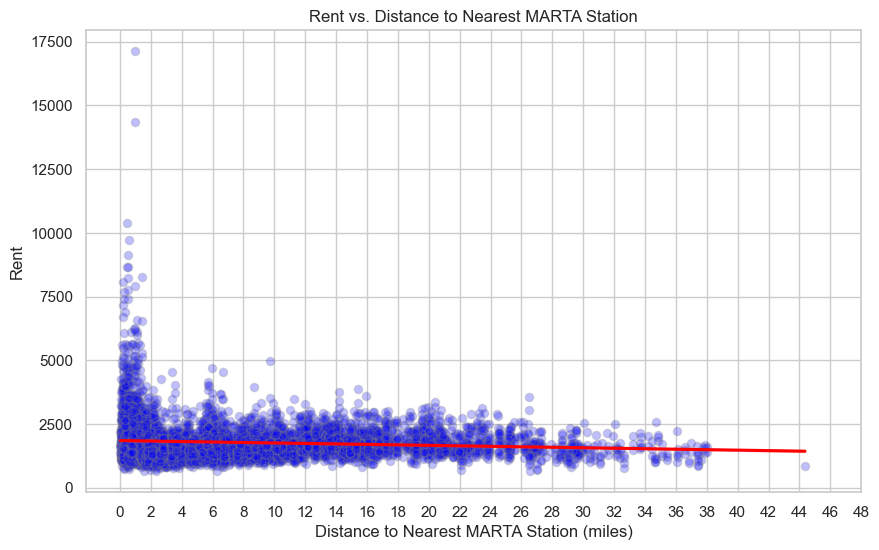

In [16]:
#plot rent vs nearest marta station
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 6))
sns.regplot(
    data=model_df1, x='nearest_marta_distance', y='rent',
    scatter_kws={"color": "blue", "alpha": 0.25, "edgecolor": "gray"}, line_kws={"color": "red"},
)
plt.title("Rent vs. Distance to Nearest MARTA Station")
plt.xlabel("Distance to Nearest MARTA Station (miles)")
plt.xticks(np.arange(0, 50, 2))
plt.ylabel("Rent")
plt.show()

In [17]:
#test model with new feature (nearest MARTA Station)

X, y_log, groups = prepare_cv_data(model_df1, combined_df)

model1_avg_mae = train_model_cv(X, y_log, groups, cat_cols)

X: (6887, 72), unique properties: 2121
Training until validation scores don't improve for 50 rounds
[50]	train's l1: 0.0389127	valid's l1: 0.0437204
[100]	train's l1: 0.0265906	valid's l1: 0.0363953
Early stopping, best iteration is:
[93]	train's l1: 0.0271575	valid's l1: 0.0363541
Fold 0: best_iter=93, MAE=$70.69
Training until validation scores don't improve for 50 rounds
[50]	train's l1: 0.0388979	valid's l1: 0.0429717
[100]	train's l1: 0.026612	valid's l1: 0.0361244
[150]	train's l1: 0.0239788	valid's l1: 0.0362161
Early stopping, best iteration is:
[110]	train's l1: 0.0259843	valid's l1: 0.0358669
Fold 1: best_iter=110, MAE=$76.26
Training until validation scores don't improve for 50 rounds
[50]	train's l1: 0.0393289	valid's l1: 0.0427735
[100]	train's l1: 0.0269893	valid's l1: 0.0346256
[150]	train's l1: 0.0243721	valid's l1: 0.0347101
Early stopping, best iteration is:
[110]	train's l1: 0.0262906	valid's l1: 0.03431
Fold 2: best_iter=110, MAE=$76.59
Training until validation sco

In [18]:
model_maes = {}
model_maes['base'] = 0

#function to compare results
def compare_avg_mae(old_avg_mae, new_avg_mae, feature_name):
    change = new_avg_mae - base_avg_mae
    pct_change = (change / base_avg_mae) * 100
    model_maes[feature_name] = change
    
    print(f"\nOld OOF Avg MAE:  ${old_avg_mae:,.2f}")
    print(f"New OOF Avg MAE:  ${new_avg_mae:,.2f}")
    print(f"Change: ${change:+,.2f} ({pct_change:+.2f}%)\n")


#compare
compare_avg_mae(base_avg_mae, model1_avg_mae, 'dist to nearest marta')


Old OOF Avg MAE:  $77.49
New OOF Avg MAE:  $77.20
Change: $-0.29 (-0.38%)



In [19]:
#new model test
#transform nearest_marta col into ordinal data
bins = [0, 0.5, 2.5, 5, 20, float('inf')]
labels = ['<0.5 mi', '0.5-2.5 mi', '2.5-5 mi', '5-20 mi', '20+ mi']

model_df2 = model_df1.copy()
model_df2['nearest_marta_distance_ordinal'] = pd.Categorical(
    pd.cut(model_df2['nearest_marta_distance'], bins=bins, labels=labels),
    ordered=True
)
print(model_df2['nearest_marta_distance_ordinal'].value_counts().sort_index())

nearest_marta_distance_ordinal
<0.5 mi        679
0.5-2.5 mi    1973
2.5-5 mi       891
5-20 mi       2718
20+ mi         626
Name: count, dtype: int64


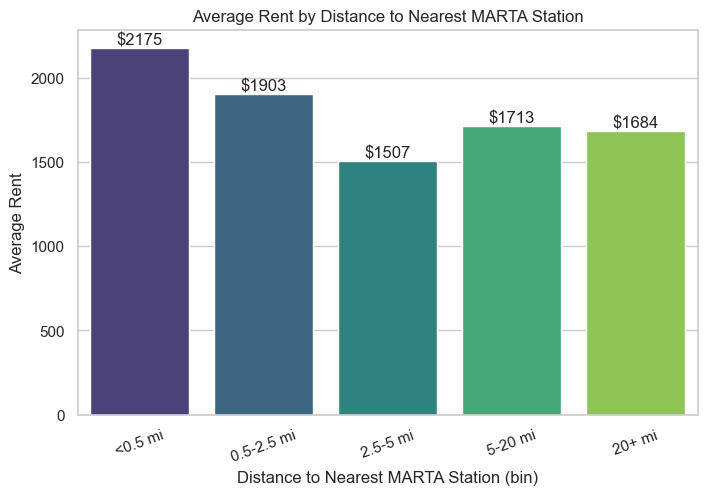

In [20]:
plt.figure(figsize=(8, 5))
avg_rent = model_df2.groupby('nearest_marta_distance_ordinal', observed=True)['rent'].mean()

barplot = sns.barplot(
    x=avg_rent.index.astype(str), y=avg_rent.values,
    hue=avg_rent.index.astype(str), palette='viridis', legend=False
)
plt.title("Average Rent by Distance to Nearest MARTA Station")
plt.xlabel("Distance to Nearest MARTA Station (bin)")
plt.ylabel("Average Rent")
plt.xticks(rotation=20)
for container in barplot.containers:
    barplot.bar_label(container, fmt='$%.0f')
plt.show()

In [21]:
#change ordinal column to numeric
model_df2['nearest_marta_distance_ordinal'] = model_df2['nearest_marta_distance_ordinal'].cat.codes

#exclude it from cat_cols so LightGBM treats it as numeric, not nominal categorical
cat_cols = [c for c in cat_cols if c != 'nearest_marta_distance_ordinal']

In [22]:
#test model with new feature (nearest MARTA distance ordinal)

X, y_log, groups = prepare_cv_data(model_df2, combined_df)

model2_avg_mae = train_model_cv(X, y_log, groups, cat_cols)

X: (6887, 73), unique properties: 2121
Training until validation scores don't improve for 50 rounds
[50]	train's l1: 0.0390089	valid's l1: 0.0439456
[100]	train's l1: 0.0264382	valid's l1: 0.0367225
[150]	train's l1: 0.0238596	valid's l1: 0.036732
Early stopping, best iteration is:
[120]	train's l1: 0.0252647	valid's l1: 0.0364901
Fold 0: best_iter=120, MAE=$70.59
Training until validation scores don't improve for 50 rounds
[50]	train's l1: 0.0390461	valid's l1: 0.0430079
[100]	train's l1: 0.0266665	valid's l1: 0.0363405
[150]	train's l1: 0.0239687	valid's l1: 0.0362398
Early stopping, best iteration is:
[140]	train's l1: 0.0244254	valid's l1: 0.0361239
Fold 1: best_iter=140, MAE=$76.51
Training until validation scores don't improve for 50 rounds
[50]	train's l1: 0.0393784	valid's l1: 0.042176
[100]	train's l1: 0.0269472	valid's l1: 0.0338302
[150]	train's l1: 0.0242777	valid's l1: 0.0335929
Early stopping, best iteration is:
[133]	train's l1: 0.0250725	valid's l1: 0.0335528
Fold 2: be

In [23]:
#compare mae
compare_avg_mae(base_avg_mae, model2_avg_mae, 'dist to nearest marta (bins)')


Old OOF Avg MAE:  $77.49
New OOF Avg MAE:  $76.59
Change: $-0.90 (-1.17%)



## Airport Promximity

In [24]:
model_df3 = base_model_df.copy()

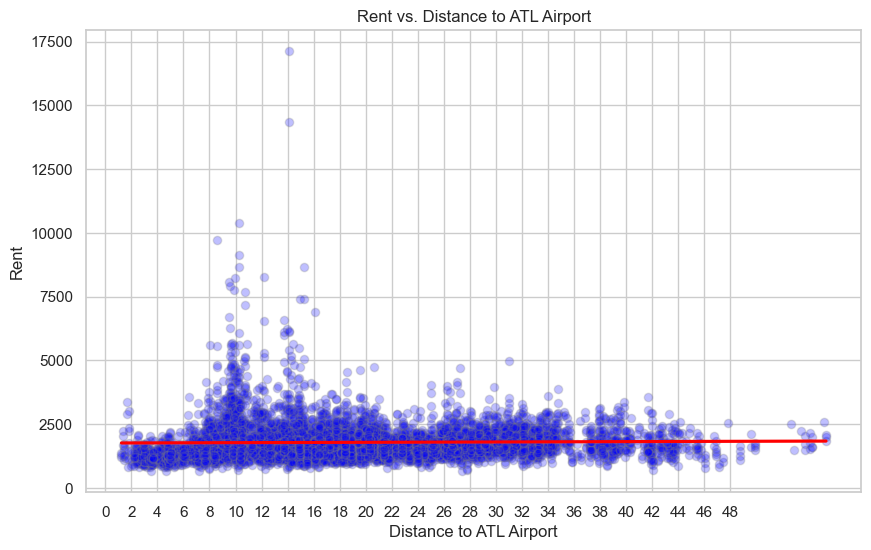

In [25]:
#plot rent vs distance to atl airport
plt.figure(figsize=(10, 6))
sns.regplot(
    data=model_df3, x='distance_to_atl_airport', y='rent',
    scatter_kws={"color": "blue", "alpha": 0.25, "edgecolor": "gray"}, line_kws={"color": "red"},
)
plt.title("Rent vs. Distance to ATL Airport")
plt.xlabel("Distance to ATL Airport")
plt.xticks(np.arange(0, 50, 2))
plt.ylabel("Rent")
plt.show()

In [26]:
#transform airport_dist col into ordinal data
bins = [0, 8, 15, float('inf')]
labels = ['0-8 mi', '8-15 mi', '15+ mi']

model_df3['distance_to_atl_airport_ordinal'] = pd.Categorical(
    pd.cut(model_df3['distance_to_atl_airport'], bins=bins, labels=labels),
    ordered=True
)

print(model_df3['distance_to_atl_airport_ordinal'].value_counts().sort_index())

distance_to_atl_airport_ordinal
0-8 mi      856
8-15 mi    1941
15+ mi     4090
Name: count, dtype: int64


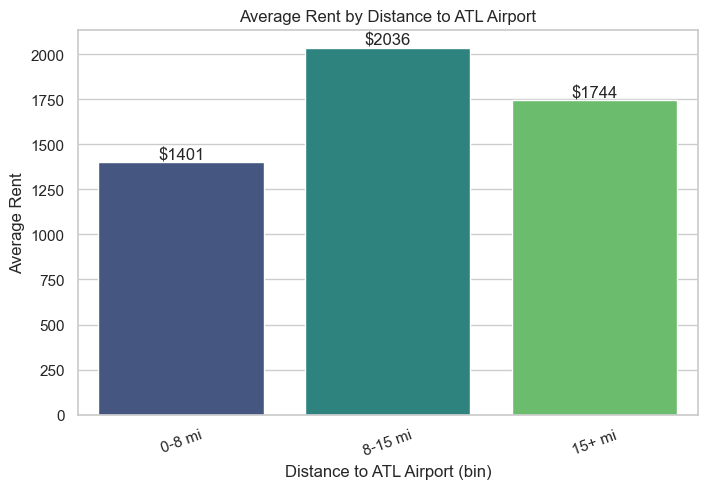

In [27]:
plt.figure(figsize=(8, 5))
avg_rent = model_df3.groupby('distance_to_atl_airport_ordinal', observed=True)['rent'].mean()

barplot = sns.barplot(
    x=avg_rent.index.astype(str), y=avg_rent.values,
    hue=avg_rent.index.astype(str), palette='viridis', legend=False
)
plt.title("Average Rent by Distance to ATL Airport")
plt.xlabel("Distance to ATL Airport (bin)")
plt.ylabel("Average Rent")
plt.xticks(rotation=20)
for container in barplot.containers:
    barplot.bar_label(container, fmt='$%.0f')
plt.show()

In [28]:
#test model with new feature (distance to airport ordinal)

X, y_log, groups = prepare_cv_data(model_df3, combined_df)

model3_avg_mae = train_model_cv(X, y_log, groups, cat_cols)

X: (6887, 72), unique properties: 2121
Training until validation scores don't improve for 50 rounds
[50]	train's l1: 0.038947	valid's l1: 0.0438886
[100]	train's l1: 0.0264265	valid's l1: 0.0363187
[150]	train's l1: 0.0237268	valid's l1: 0.0363936
Early stopping, best iteration is:
[126]	train's l1: 0.0248359	valid's l1: 0.0360123
Fold 0: best_iter=126, MAE=$69.80
Training until validation scores don't improve for 50 rounds
[50]	train's l1: 0.0389655	valid's l1: 0.0431062
[100]	train's l1: 0.0266559	valid's l1: 0.0361242
[150]	train's l1: 0.0239486	valid's l1: 0.0364792
Early stopping, best iteration is:
[108]	train's l1: 0.0261612	valid's l1: 0.0361089
Fold 1: best_iter=108, MAE=$76.31
Training until validation scores don't improve for 50 rounds
[50]	train's l1: 0.0393764	valid's l1: 0.0428244
[100]	train's l1: 0.027135	valid's l1: 0.0339399
[150]	train's l1: 0.0243966	valid's l1: 0.0340837
Early stopping, best iteration is:
[127]	train's l1: 0.0255198	valid's l1: 0.0337694
Fold 2: be

In [29]:
#compare mae
compare_avg_mae(base_avg_mae, model3_avg_mae, 'dist to atl airport (bins)')


Old OOF Avg MAE:  $77.49
New OOF Avg MAE:  $77.29
Change: $-0.20 (-0.26%)



## Buckhead Proximity

In [30]:
model_df4 = base_model_df.copy()

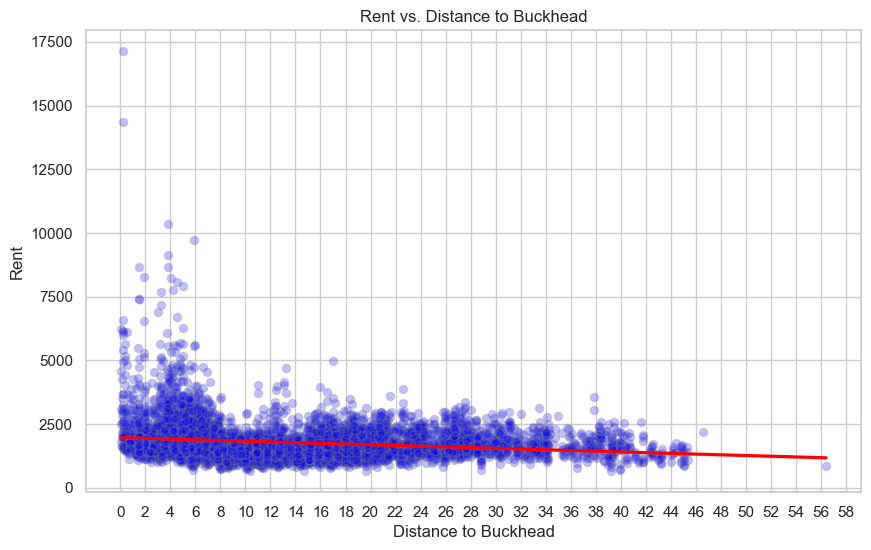

In [31]:
#plot rent vs distance to Buckhead
plt.figure(figsize=(10, 6))
sns.regplot(
    data=model_df4, x='distance_to_buckhead', y='rent',
    scatter_kws={"color": "blue", "alpha": 0.25, "edgecolor": "gray"}, line_kws={"color": "red"},
)
plt.title("Rent vs. Distance to Buckhead")
plt.xlabel("Distance to Buckhead")
plt.xticks(np.arange(0, 60, 2))
plt.ylabel("Rent")
plt.show()

In [32]:
#transform buckhead_dist col into bool data
model_df4['distance_to_buckhead_<_6'] = model_df4['distance_to_buckhead'] < 6
model_df4['distance_to_buckhead_<_6'].value_counts()

distance_to_buckhead_<_6
False    5172
True     1715
Name: count, dtype: int64

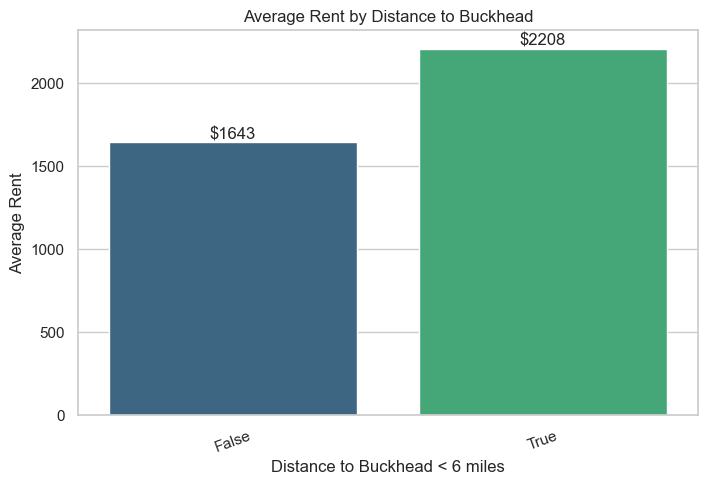

In [33]:
plt.figure(figsize=(8, 5))
avg_rent = model_df4.groupby('distance_to_buckhead_<_6', observed=True)['rent'].mean()

barplot = sns.barplot(
    x=avg_rent.index.astype(str), y=avg_rent.values,
    hue=avg_rent.index.astype(str), palette='viridis', legend=False
)
plt.title("Average Rent by Distance to Buckhead")
plt.xlabel("Distance to Buckhead < 6 miles")
plt.ylabel("Average Rent")
plt.xticks(rotation=20)
for container in barplot.containers:
    barplot.bar_label(container, fmt='$%.0f')
plt.show()

In [34]:
#test model with new feature (distance to airport ordinal)

X, y_log, groups = prepare_cv_data(model_df4, combined_df)

model4_avg_mae = train_model_cv(X, y_log, groups, cat_cols)

X: (6887, 72), unique properties: 2121
Training until validation scores don't improve for 50 rounds
[50]	train's l1: 0.038947	valid's l1: 0.0438886
[100]	train's l1: 0.0264265	valid's l1: 0.0363187
[150]	train's l1: 0.0237268	valid's l1: 0.0363936
Early stopping, best iteration is:
[126]	train's l1: 0.0248359	valid's l1: 0.0360123
Fold 0: best_iter=126, MAE=$69.80
Training until validation scores don't improve for 50 rounds
[50]	train's l1: 0.0388733	valid's l1: 0.0427598
[100]	train's l1: 0.026499	valid's l1: 0.0359427
[150]	train's l1: 0.0238356	valid's l1: 0.0361338
Early stopping, best iteration is:
[120]	train's l1: 0.0252755	valid's l1: 0.0358017
Fold 1: best_iter=120, MAE=$76.17
Training until validation scores don't improve for 50 rounds
[50]	train's l1: 0.0393764	valid's l1: 0.0428244
[100]	train's l1: 0.027135	valid's l1: 0.0339399
[150]	train's l1: 0.0243966	valid's l1: 0.0340837
Early stopping, best iteration is:
[127]	train's l1: 0.0255198	valid's l1: 0.0337694
Fold 2: bes

In [35]:
#compare mae
compare_avg_mae(base_avg_mae, model4_avg_mae, 'distance to buckhead (bins)')


Old OOF Avg MAE:  $77.49
New OOF Avg MAE:  $77.28
Change: $-0.22 (-0.28%)



## POI Densities (Walk Score)

### Grocery Stores

In [36]:
#load grocery geojson from OSM
grocery_landmarks = load_geojson_points("/Users/njlim21/Desktop/forty5park/prime-mfr/eda/grocery.geojson")

In [37]:
#disambiguate duplicates with a numeric suffix
def disambiguate_dups(df):
    df['key'] = df['name'].str.lower().str.replace(' ', '_', regex=False)
    dup_count = df.groupby('key').cumcount()
    df['key'] = np.where(
        dup_count == 0,
        df['key'],
        df['key'] + '_' + (dup_count + 1).astype(str)
    )
    
    df['name'] = df['key']
    df.drop(columns='key', inplace=True)

    return df


disambiguate_dups(grocery_landmarks)

,name,latitude,longitude
0,walmart_supercenter,33.719117,-84.312911
1,walmart_supercenter_2,34.093656,-84.274436
2,publix,33.811372,-84.274709
3,publix_2,33.813526,-84.311357
4,kroger,33.815596,-84.313926
...,...,...,...
683,food_depot_20,33.563742,-85.113770
684,unknown_8,33.594330,-83.968341
685,lidl_18,33.784083,-84.407771
686,o4w_market,33.752226,-84.370183


In [38]:
#add to landmarks_df
landmarks_df = pd.concat([landmarks_df, grocery_landmarks], ignore_index=True)

#fill key and type cols
landmarks_df = landmarks_df_fill_cols(landmarks_df, 'grocery')
landmarks_df.tail()

,key,name,type,latitude,longitude,source
725,food_depot_20,food_depot_20,grocery,33.563742,-85.113770,NaN
726,unknown_8,unknown_8,grocery,33.594330,-83.968341,NaN
727,lidl_18,lidl_18,grocery,33.784083,-84.407771,NaN
728,o4w_market,o4w_market,grocery,33.752226,-84.370183,NaN
729,al_madina_halal_market_and_restaurant,al_madina_halal_market_and_restaurant,grocery,33.904122,-84.204841,NaN


In [39]:
#compute distance from each property to every POI
grocery_dist_df, grocery_lat_lon_df = poi_dist_to_each_property(landmarks_df, 'grocery')

In [40]:
#create feature for how many POI's are within a 0.25 mile radius
grocery_lat_lon_df['num_grocery_stores_within_0.25_mile'] = (
    grocery_dist_df.drop(columns=['num_grocery_stores_within_0.25_mile'], errors='ignore') < 0.25).sum(axis=1)

#add feature to a new model_df
model_df5 = base_model_df.join(grocery_lat_lon_df['num_grocery_stores_within_0.25_mile'])

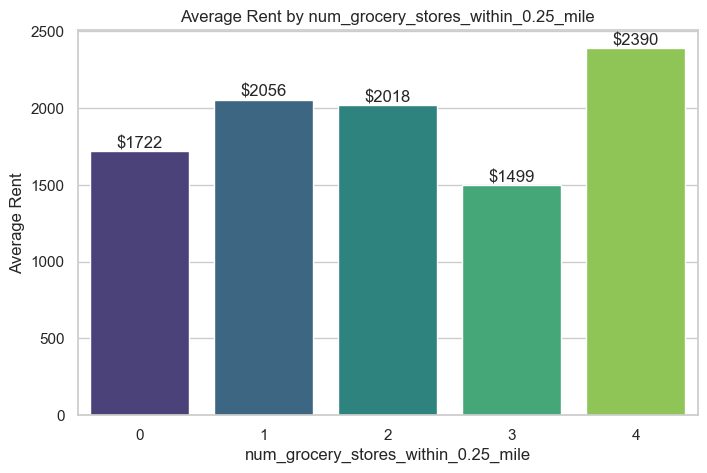

In [41]:
plt.figure(figsize=(8, 5))
avg_rent = model_df5.groupby('num_grocery_stores_within_0.25_mile', observed=True)['rent'].mean()

barplot = sns.barplot(
    x=avg_rent.index.astype(str), y=avg_rent.values,
    hue=avg_rent.index.astype(str), palette='viridis', legend=False
)
plt.title("Average Rent by num_grocery_stores_within_0.25_mile")
plt.xlabel("num_grocery_stores_within_0.25_mile")
plt.ylabel("Average Rent")
for container in barplot.containers:
    barplot.bar_label(container, fmt='$%.0f')
plt.show()

In [42]:
#test model with new feature (num grocery stores within 0.25 mile)

X, y_log, groups = prepare_cv_data(model_df5, combined_df)

model5_avg_mae = train_model_cv(X, y_log, groups, cat_cols)

X: (6887, 72), unique properties: 2121
Training until validation scores don't improve for 50 rounds
[50]	train's l1: 0.0389912	valid's l1: 0.0436903
[100]	train's l1: 0.026409	valid's l1: 0.0359705
[150]	train's l1: 0.0237566	valid's l1: 0.0359134
Early stopping, best iteration is:
[112]	train's l1: 0.0256044	valid's l1: 0.0357149
Fold 0: best_iter=112, MAE=$69.47
Training until validation scores don't improve for 50 rounds
[50]	train's l1: 0.0388828	valid's l1: 0.0429581
[100]	train's l1: 0.0265579	valid's l1: 0.0364174
[150]	train's l1: 0.0238781	valid's l1: 0.0361099
Early stopping, best iteration is:
[126]	train's l1: 0.0249237	valid's l1: 0.0358978
Fold 1: best_iter=126, MAE=$76.48
Training until validation scores don't improve for 50 rounds
[50]	train's l1: 0.0393406	valid's l1: 0.0427745
[100]	train's l1: 0.0270039	valid's l1: 0.0342177
[150]	train's l1: 0.0243126	valid's l1: 0.0343837
Early stopping, best iteration is:
[110]	train's l1: 0.026368	valid's l1: 0.0341185
Fold 2: be

In [43]:
#compare mae
compare_avg_mae(base_avg_mae, model5_avg_mae, 'grocery POI density')


Old OOF Avg MAE:  $77.49
New OOF Avg MAE:  $77.37
Change: $-0.12 (-0.16%)



### Cafes

In [44]:
#load cafe geojson from OSM
cafe_landmarks = load_geojson_points("/Users/njlim21/Desktop/forty5park/prime-mfr/eda/cafes.geojson")

#disambiguate
disambiguate_dups(cafe_landmarks)

#add to landmarks_df
landmarks_df = pd.concat([landmarks_df, cafe_landmarks], ignore_index=True)

#fill key and type cols
landmarks_df = landmarks_df_fill_cols(landmarks_df, 'cafe')
landmarks_df.tail()

,key,name,type,latitude,longitude,source
1025,moody_brews_coffee,moody_brews_coffee,cafe,34.188018,-84.145193,NaN
1026,7_brew_coffee,7_brew_coffee,cafe,33.908167,-84.003477,NaN
1027,starbucks_168,starbucks_168,cafe,34.017207,-84.191375,NaN
1028,summit_coffee,summit_coffee,cafe,33.859159,-84.340215,NaN
1029,break_coffee_roasters,break_coffee_roasters,cafe,34.003363,-84.145827,NaN


In [45]:
#compute distance from each property to every POI
cafe_dist_df, cafe_lat_lon_df = poi_dist_to_each_property(landmarks_df, 'cafe')

In [46]:
#create feature for how many POI's are within a 0.25 mile radius
cafe_lat_lon_df['num_cafes_within_0.25_mile'] = (
    cafe_dist_df.drop(columns=['num_cafes_within_0.25_mile'], errors='ignore') < 0.25).sum(axis=1)

#add feature to a new model_df
model_df6 = base_model_df.join(cafe_lat_lon_df['num_cafes_within_0.25_mile'])

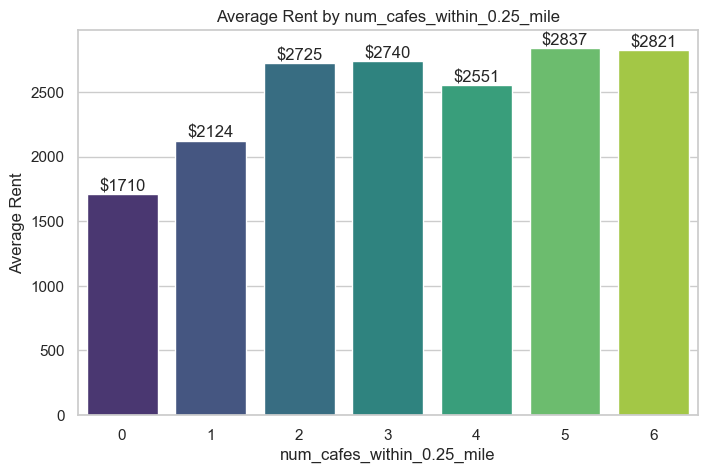

In [47]:
plt.figure(figsize=(8, 5))
avg_rent = model_df6.groupby('num_cafes_within_0.25_mile', observed=True)['rent'].mean()

barplot = sns.barplot(
    x=avg_rent.index.astype(str), y=avg_rent.values,
    hue=avg_rent.index.astype(str), palette='viridis', legend=False
)
plt.title("Average Rent by num_cafes_within_0.25_mile")
plt.xlabel("num_cafes_within_0.25_mile")
plt.ylabel("Average Rent")
for container in barplot.containers:
    barplot.bar_label(container, fmt='$%.0f')
plt.show()

In [48]:
#test model with new feature (num cafes within 0.25 mile)

X, y_log, groups = prepare_cv_data(model_df6, combined_df)

model6_avg_mae = train_model_cv(X, y_log, groups, cat_cols)

X: (6887, 72), unique properties: 2121
Training until validation scores don't improve for 50 rounds
[50]	train's l1: 0.0389475	valid's l1: 0.0438547
[100]	train's l1: 0.0263363	valid's l1: 0.0363141
[150]	train's l1: 0.0235496	valid's l1: 0.0363689
Early stopping, best iteration is:
[110]	train's l1: 0.025586	valid's l1: 0.0361222
Fold 0: best_iter=110, MAE=$70.17
Training until validation scores don't improve for 50 rounds
[50]	train's l1: 0.0389655	valid's l1: 0.0431062
[100]	train's l1: 0.0266932	valid's l1: 0.0362961
[150]	train's l1: 0.0240473	valid's l1: 0.036072
Early stopping, best iteration is:
[127]	train's l1: 0.0250313	valid's l1: 0.0358985
Fold 1: best_iter=127, MAE=$75.76
Training until validation scores don't improve for 50 rounds
[50]	train's l1: 0.0394455	valid's l1: 0.0426556
[100]	train's l1: 0.0269975	valid's l1: 0.0340962
[150]	train's l1: 0.0243645	valid's l1: 0.0339427
Early stopping, best iteration is:
[129]	train's l1: 0.0253619	valid's l1: 0.0337393
Fold 2: be

In [49]:
#compare mae
compare_avg_mae(base_avg_mae, model6_avg_mae, 'cafe POI density')


Old OOF Avg MAE:  $77.49
New OOF Avg MAE:  $77.15
Change: $-0.34 (-0.44%)



### Offices

In [50]:
#load office geojson from OSM
office_landmarks = load_geojson_points("/Users/njlim21/Desktop/forty5park/prime-mfr/eda/offices.geojson")

#disambiguate
disambiguate_dups(office_landmarks)

#add to landmarks_df
landmarks_df = pd.concat([landmarks_df, office_landmarks], ignore_index=True)

#fill key and type cols
landmarks_df = landmarks_df_fill_cols(landmarks_df, 'office')
landmarks_df.tail()

,key,name,type,latitude,longitude,source
1254,crowne_office_suites_cumberland,crowne_office_suites_cumberland,office,33.905985,-84.478635,NaN
1255,midway_limousine_services,midway_limousine_services,office,33.901774,-84.482679,NaN
1256,boyzo_trucks,boyzo_trucks,office,33.885883,-84.258284,NaN
1257,lumien_lighting,lumien_lighting,office,33.986926,-84.553954,NaN
1258,development_and_support_center,development_and_support_center,office,33.925089,-84.246819,NaN


In [51]:
#compute distance from each property to every POI
office_dist_df, office_lat_lon_df = poi_dist_to_each_property(landmarks_df, 'office')

In [52]:
#create feature for how many POI's are within a 0.25 mile radius
office_lat_lon_df['num_offices_within_0.25_mile'] = (
    office_dist_df.drop(columns=['num_offices_within_0.25_mile'], errors='ignore') < 0.25).sum(axis=1)

#add feature to a new model_df
model_df7 = base_model_df.join(office_lat_lon_df['num_offices_within_0.25_mile'])

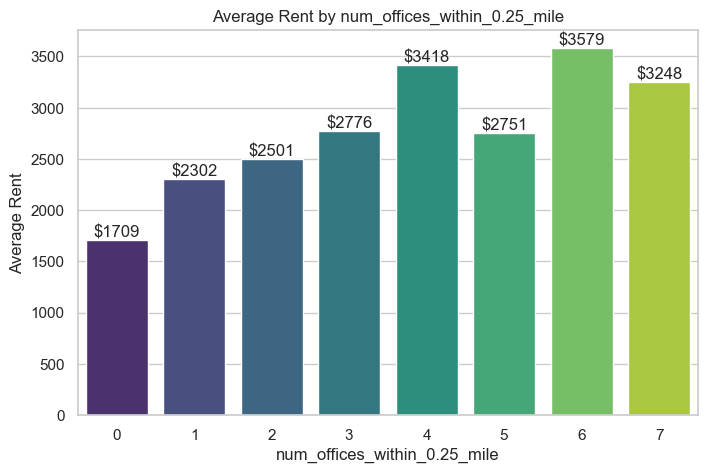

In [53]:
plt.figure(figsize=(8, 5))
avg_rent = model_df7.groupby('num_offices_within_0.25_mile', observed=True)['rent'].mean()

barplot = sns.barplot(
    x=avg_rent.index.astype(str), y=avg_rent.values,
    hue=avg_rent.index.astype(str), palette='viridis', legend=False
)
plt.title("Average Rent by num_offices_within_0.25_mile")
plt.xlabel("num_offices_within_0.25_mile")
plt.ylabel("Average Rent")
for container in barplot.containers:
    barplot.bar_label(container, fmt='$%.0f')
plt.show()

In [54]:
#test model with new feature (num offices within 0.25 mile)

X, y_log, groups = prepare_cv_data(model_df7, combined_df)

model7_avg_mae = train_model_cv(X, y_log, groups, cat_cols)

X: (6887, 72), unique properties: 2121
Training until validation scores don't improve for 50 rounds
[50]	train's l1: 0.0389372	valid's l1: 0.0438479
[100]	train's l1: 0.0263577	valid's l1: 0.0363407
[150]	train's l1: 0.023577	valid's l1: 0.0364138
Early stopping, best iteration is:
[110]	train's l1: 0.0255971	valid's l1: 0.03617
Fold 0: best_iter=110, MAE=$69.96
Training until validation scores don't improve for 50 rounds
[50]	train's l1: 0.0388935	valid's l1: 0.0427299
[100]	train's l1: 0.0266405	valid's l1: 0.0360753
Early stopping, best iteration is:
[86]	train's l1: 0.027814	valid's l1: 0.0358722
Fold 1: best_iter=86, MAE=$75.34
Training until validation scores don't improve for 50 rounds
[50]	train's l1: 0.0394199	valid's l1: 0.0428019
[100]	train's l1: 0.0270816	valid's l1: 0.034446
[150]	train's l1: 0.0243582	valid's l1: 0.0345124
Early stopping, best iteration is:
[127]	train's l1: 0.0254379	valid's l1: 0.0342884
Fold 2: best_iter=127, MAE=$76.08
Training until validation score

In [55]:
#compare mae
compare_avg_mae(base_avg_mae, model7_avg_mae, 'office POI density')


Old OOF Avg MAE:  $77.49
New OOF Avg MAE:  $77.15
Change: $-0.34 (-0.44%)



### Bars/NightClubs

In [56]:
#load office geojson from OSM
bars_landmarks = load_geojson_points("/Users/njlim21/Desktop/forty5park/prime-mfr/eda/bars.geojson")

#disambiguate
disambiguate_dups(bars_landmarks)

#add to landmarks_df
landmarks_df = pd.concat([landmarks_df, bars_landmarks], ignore_index=True)

#fill key and type cols
landmarks_df = landmarks_df_fill_cols(landmarks_df, 'bar')
landmarks_df.tail()

,key,name,type,latitude,longitude,source
1454,the_bar_2,the_bar_2,bar,33.803005,-84.412576,NaN
1455,woofs_sports_bar,woofs_sports_bar,bar,33.811625,-84.372623,NaN
1456,mazzy's_sports_tavern,mazzy's_sports_tavern,bar,33.951251,-84.140209,NaN
1457,bo's_tavern,bo's_tavern,bar,33.818804,-84.813417,NaN
1458,peachtree_sports_club,peachtree_sports_club,bar,33.759570,-84.387133,NaN


In [57]:
#compute distance from each property to every POI
bars_dist_df, bars_lat_lon_df = poi_dist_to_each_property(landmarks_df, 'bar')

In [58]:
#create feature for how many POI's are within a 0.25 mile radius
bars_lat_lon_df['num_bars_within_0.25_mile'] = (
    bars_dist_df.drop(columns=['num_bars_within_0.25_mile'], errors='ignore') < 0.25).sum(axis=1)

#add feature to a new model_df
model_df8 = base_model_df.join(bars_lat_lon_df['num_bars_within_0.25_mile'])

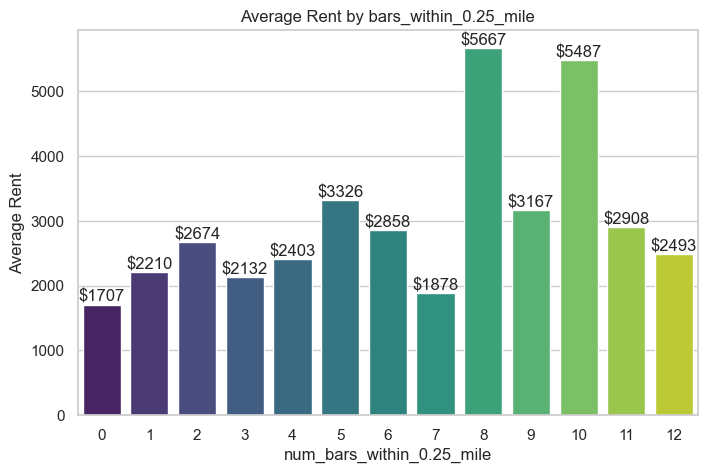

In [59]:
plt.figure(figsize=(8, 5))
avg_rent = model_df8.groupby('num_bars_within_0.25_mile', observed=True)['rent'].mean()

barplot = sns.barplot(
    x=avg_rent.index.astype(str), y=avg_rent.values,
    hue=avg_rent.index.astype(str), palette='viridis', legend=False
)
plt.title("Average Rent by bars_within_0.25_mile")
plt.xlabel("num_bars_within_0.25_mile")
plt.ylabel("Average Rent")
for container in barplot.containers:
    barplot.bar_label(container, fmt='$%.0f')
plt.show()

In [60]:
#test model with new feature (num bars within 0.25 mile)

X, y_log, groups = prepare_cv_data(model_df8, combined_df)

model8_avg_mae = train_model_cv(X, y_log, groups, cat_cols)

X: (6887, 72), unique properties: 2121
Training until validation scores don't improve for 50 rounds
[50]	train's l1: 0.0390368	valid's l1: 0.0438212
[100]	train's l1: 0.0263418	valid's l1: 0.036249
Early stopping, best iteration is:
[95]	train's l1: 0.0267372	valid's l1: 0.0362004
Fold 0: best_iter=95, MAE=$70.27
Training until validation scores don't improve for 50 rounds
[50]	train's l1: 0.0389502	valid's l1: 0.0428197
[100]	train's l1: 0.02675	valid's l1: 0.0360913
[150]	train's l1: 0.0241114	valid's l1: 0.0362046
Early stopping, best iteration is:
[110]	train's l1: 0.0261559	valid's l1: 0.0359385
Fold 1: best_iter=110, MAE=$76.27
Training until validation scores don't improve for 50 rounds
[50]	train's l1: 0.0393856	valid's l1: 0.0425187
[100]	train's l1: 0.0271067	valid's l1: 0.0347117
[150]	train's l1: 0.0244233	valid's l1: 0.0346725
Early stopping, best iteration is:
[139]	train's l1: 0.0249233	valid's l1: 0.034413
Fold 2: best_iter=139, MAE=$76.27
Training until validation scor

In [61]:
#compare mae
compare_avg_mae(base_avg_mae, model8_avg_mae, 'bars/clubs POI density')


Old OOF Avg MAE:  $77.49
New OOF Avg MAE:  $77.82
Change: $+0.33 (+0.42%)



## Top Schools Proximity

In [62]:
school_landmarks = load_geojson_points("/Users/njlim21/Desktop/forty5park/prime-mfr/eda/top_private_schools.geojson")
school_landmarks = school_landmarks.drop(school_landmarks.index[1]).reset_index(drop=True)

#disambiguate
disambiguate_dups(school_landmarks)

#add to landmarks_df
landmarks_df = pd.concat([landmarks_df, school_landmarks], ignore_index=True)

#fill key and type cols
landmarks_df = landmarks_df_fill_cols(landmarks_df, 'top_school')
landmarks_df.tail()

,key,name,type,latitude,longitude,source
1459,pace_academy,pace_academy,top_school,33.848100,-84.417147,NaN
1460,atlanta_international_school,atlanta_international_school,top_school,33.833835,-84.379133,NaN
1461,the_westminster_schools,the_westminster_schools,top_school,33.842652,-84.434750,NaN
1462,fulton_science_academy,fulton_science_academy,top_school,34.051504,-84.299774,NaN
1463,paideia_school,paideia_school,top_school,33.773566,-84.340308,NaN


In [63]:
#compute distance from each property to every POI
schools_dist_df, schools_lat_lon_df = poi_dist_to_each_property(landmarks_df, 'top_school')

In [64]:
#find the nearest top school and its distance
valid_rows = marta_lat_lon_df.notna().any(axis=1)
schools_lat_lon_df['nearest_top_school'] = pd.Series(np.nan, index=schools_lat_lon_df.index, dtype=object)
schools_lat_lon_df['nearest_top_school_distance'] = np.nan

schools_lat_lon_df.loc[valid_rows, 'nearest_top_school'] = schools_dist_df.loc[valid_rows].idxmin(axis=1)
schools_lat_lon_df.loc[valid_rows, 'nearest_top_school_distance'] = schools_dist_df.loc[valid_rows].min(axis=1)

#add nearest top school distance to a new model_df
model_df9 = base_model_df.join(schools_lat_lon_df['nearest_top_school_distance'])

/var/folders/sx/40d4w0391ls8cd1mgbf6ftbm0000gn/T/ipykernel_21532/1635491821.py:6: FutureWarning:

The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError



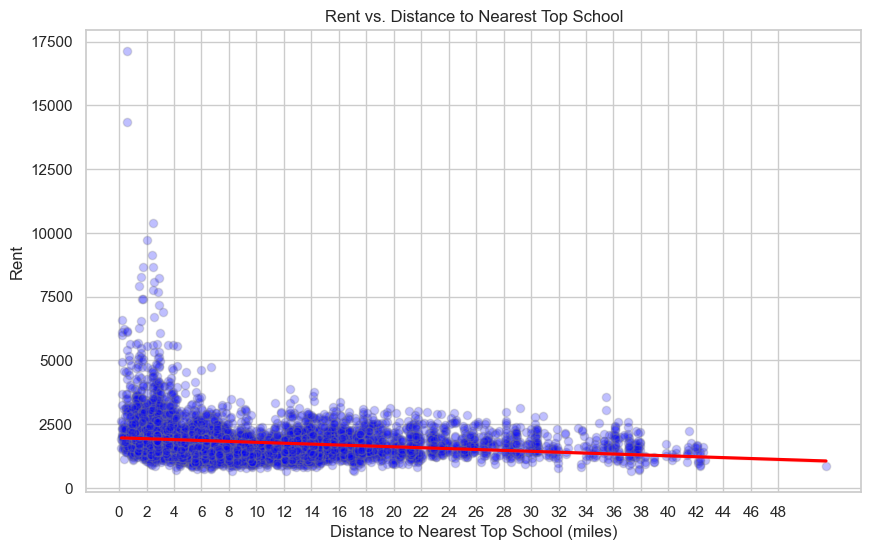

In [65]:
#plot rent vs nearest marta station
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 6))
sns.regplot(
    data=model_df9, x='nearest_top_school_distance', y='rent',
    scatter_kws={"color": "blue", "alpha": 0.25, "edgecolor": "gray"}, line_kws={"color": "red"},
)
plt.title("Rent vs. Distance to Nearest Top School")
plt.xlabel("Distance to Nearest Top School (miles)")
plt.xticks(np.arange(0, 50, 2))
plt.ylabel("Rent")
plt.show()

In [66]:
#test model with new feature (num offices within 0.25 mile)

X, y_log, groups = prepare_cv_data(model_df9, combined_df)

model9_avg_mae = train_model_cv(X, y_log, groups, cat_cols)

X: (6887, 72), unique properties: 2121
Training until validation scores don't improve for 50 rounds
[50]	train's l1: 0.038989	valid's l1: 0.0438927
[100]	train's l1: 0.026437	valid's l1: 0.0364429
[150]	train's l1: 0.0237541	valid's l1: 0.0364764
Early stopping, best iteration is:
[112]	train's l1: 0.0255721	valid's l1: 0.0362009
Fold 0: best_iter=112, MAE=$70.51
Training until validation scores don't improve for 50 rounds
[50]	train's l1: 0.0388935	valid's l1: 0.0422024
[100]	train's l1: 0.0266695	valid's l1: 0.0356858
[150]	train's l1: 0.0239731	valid's l1: 0.0354463
Early stopping, best iteration is:
[140]	train's l1: 0.0243734	valid's l1: 0.0352003
Fold 1: best_iter=140, MAE=$74.08
Training until validation scores don't improve for 50 rounds
[50]	train's l1: 0.0393213	valid's l1: 0.0425367
[100]	train's l1: 0.0269819	valid's l1: 0.034018
[150]	train's l1: 0.0242416	valid's l1: 0.0341433
Early stopping, best iteration is:
[126]	train's l1: 0.0253728	valid's l1: 0.0338223
Fold 2: bes

In [67]:
#compare mae
compare_avg_mae(base_avg_mae, model9_avg_mae, 'dist to top school')


Old OOF Avg MAE:  $77.49
New OOF Avg MAE:  $77.35
Change: $-0.15 (-0.19%)



# Summary

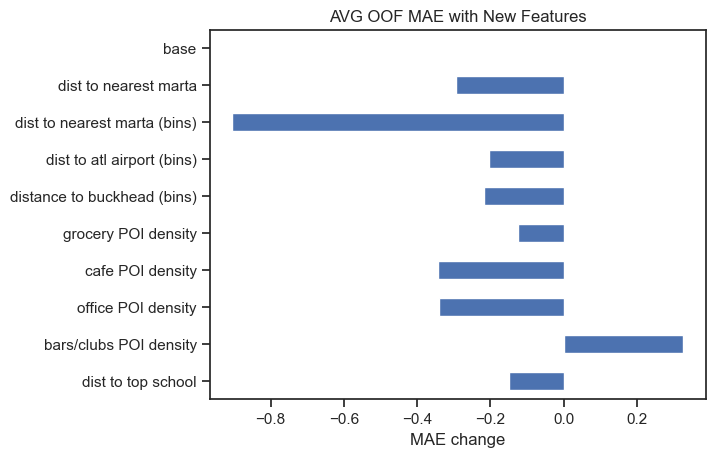

In [68]:
#plot summary results
sns.set_theme(style="ticks")

pd.Series(model_maes).plot.barh()
plt.title('AVG OOF MAE with New Features')
plt.xlabel('MAE change')
plt.gca().invert_yaxis()

plt.show()